In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv('predictive_maintenance.csv')

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [7]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [8]:
df_model = df.drop(columns=['UDI', 'Product ID'])


df_model = pd.get_dummies(df_model, columns=['Type'], drop_first=True)


X = df_model.drop(columns=['Target', 'Failure Type'])
y = df_model['Failure Type']

print(X.columns.tolist())
print(X.shape, y.shape)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']
(10000, 7) (10000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain distribution:\n", y_train.value_counts())
print("\nTest distribution:\n", y_test.value_counts())

Train shape: (8000, 7)
Test shape: (2000, 7)

Train distribution:
 Failure Type
No Failure                  7722
Heat Dissipation Failure      90
Power Failure                 76
Overstrain Failure            62
Tool Wear Failure             36
Random Failures               14
Name: count, dtype: int64

Test distribution:
 Failure Type
No Failure                  1930
Heat Dissipation Failure      22
Power Failure                 19
Overstrain Failure            16
Tool Wear Failure              9
Random Failures                4
Name: count, dtype: int64


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

baseline = DecisionTreeClassifier(random_state=42, max_depth=3)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print(classification_report(y_test, y_pred_baseline))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.00      0.00      0.00        22
              No Failure       0.97      1.00      0.98      1930
      Overstrain Failure       0.00      0.00      0.00        16
           Power Failure       0.91      0.53      0.67        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.97      2000
               macro avg       0.31      0.25      0.28      2000
            weighted avg       0.94      0.97      0.96      2000



C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, zero_division=0))

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.68      0.81        22
              No Failure       0.98      1.00      0.99      1930
      Overstrain Failure       1.00      0.56      0.72        16
           Power Failure       1.00      0.42      0.59        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.66      0.44      0.52      2000
            weighted avg       0.97      0.98      0.98      2000



In [14]:
X_train_xgb = X_train_xgb.rename(columns=lambda x: x.replace('[', '').replace(']', ''))
X_test_xgb = X_test_xgb.rename(columns=lambda x: x.replace('[', '').replace(']', ''))

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_xgb, y_train_enc)
y_pred_xgb = xgb.predict(X_test_xgb)

print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_, zero_division=0))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.95      0.86      0.90        22
              No Failure       0.99      1.00      0.99      1930
      Overstrain Failure       0.88      0.88      0.88        16
           Power Failure       0.94      0.79      0.86        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.63      0.59      0.60      2000
            weighted avg       0.98      0.98      0.98      2000



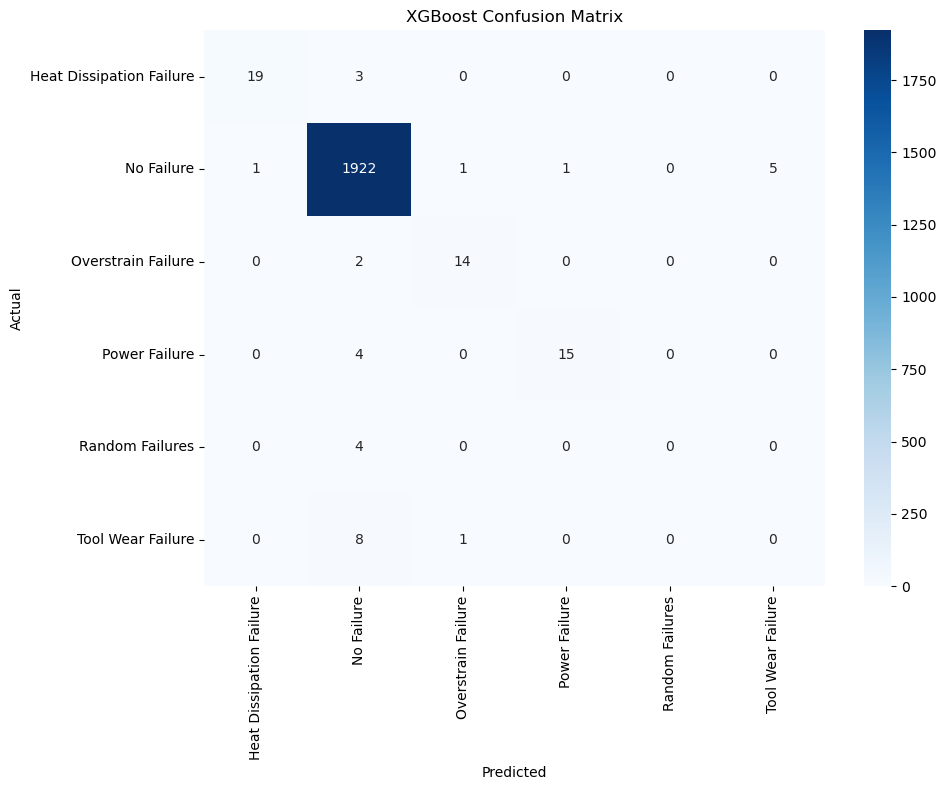

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

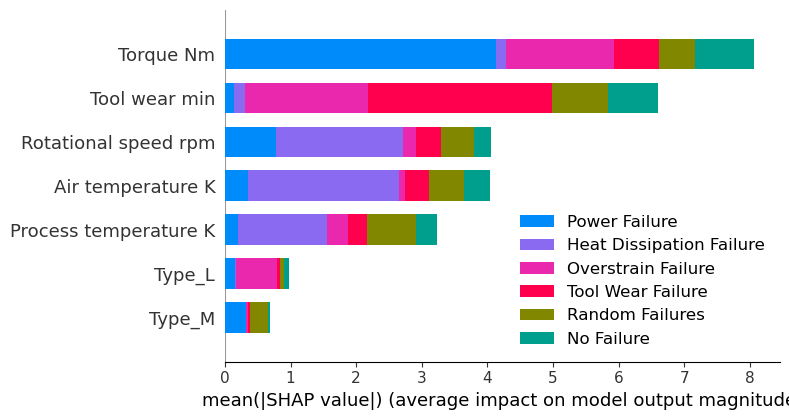

In [16]:
import shap

# Create explainer for the XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_xgb)

# Summary plot - shows feature importance across all classes
shap.summary_plot(shap_values, X_test_xgb, plot_type="bar",
                   class_names=le.classes_, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()